# 1. Descriptive Statistics

In [1]:
import pandas as pd

## 1.1 Basic Example

### 1.1.1 Download

In [2]:
def download_macro_data(url):
    """Downloads macroeconomic data from a URL and returns a pandas DataFrame."""
    print(f"Fetching macroeconomic data from: {url}")
    df = pd.read_stata(url)
    return df

In [3]:
url_macro = 'https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_unemp.dta'
df_unemp_raw = download_macro_data(url_macro)
df_unemp_raw.head(2)

Fetching macroeconomic data from: https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_unemp.dta


,ISO3,year,ADB_unemp,AFDB_unemp,AHSTAT_unemp,AMECO_unemp,EUS_unemp,HFS_unemp,ILO_unemp,IMF_IFS_unemp,IMF_WEO_unemp,JST_unemp,OECD_EO_unemp,OECD_KEI_unemp,CS1_unemp,unemp,chainlinking_ratio,source,source_change
0,ZWE,2023.0,NaN,NaN,NaN,NaN,NaN,NaN,9.348,NaN,NaN,NaN,NaN,NaN,NaN,9.348,1.0,ILO,1.0
1,ZWE,2022.0,NaN,NaN,NaN,NaN,NaN,NaN,10.087,10.139,NaN,NaN,NaN,NaN,NaN,10.139,1.0,IMF_IFS,NaN


### 1.1.2 Filter Columns

In [6]:
df_unemp = df_unemp_raw[['ISO3', 'year', 'unemp', 'EUS_unemp']]
df_unemp.head(2)

,ISO3,year,unemp,EUS_unemp
0,ZWE,2023.0,9.348,NaN
1,ZWE,2022.0,10.139,NaN


### 1.1.3 Filter country

In [52]:
df_unemp_zimbabwe = df_unemp.query("ISO3 == 'ZWE'")
df_unemp_zimbabwe.head(5)

,ISO3,year,unemp,EUS_unemp
0,ZWE,2023.0,9.348,NaN
1,ZWE,2022.0,10.139,NaN
2,ZWE,2021.0,9.540,NaN
3,ZWE,2020.0,7.373,NaN
4,ZWE,2019.0,7.373,NaN


### 1.1.4 Drop column

In [53]:
df_unemp_zimbabwe = df_unemp_zimbabwe.drop(
    ['ISO3', 'EUS_unemp'],
    axis='columns'
)

df_unemp_zimbabwe.head(5)

,year,unemp
0,2023.0,9.348
1,2022.0,10.139
2,2021.0,9.540
3,2020.0,7.373
4,2019.0,7.373


### 1.1.5 Set index

In [57]:
df_unemp_zimbabwe_final = df_unemp_zimbabwe.set_index("year")
df_unemp_zimbabwe_final


,unemp
year,
2023.0,9.348
2022.0,10.139
2021.0,9.540
2020.0,7.373
2019.0,7.373
2018.0,NaN
2017.0,NaN
2016.0,NaN
2015.0,NaN


In [58]:
df_unemp_zimbabwe_final = df_unemp_zimbabwe_final.sort_index()
df_unemp_zimbabwe_final.head(2)

,unemp
year,
1982.0,10.8
1983.0,NaN


### 1.1.6 Plot

In [66]:
f_unemp_zimbabwe_final.loc[1982:2018]

,unemp
year,
1982.0,10.800
1983.0,NaN
1984.0,NaN
1985.0,NaN
1986.0,NaN
1987.0,7.180
1988.0,NaN
1989.0,NaN
1990.0,NaN


### 1.1.6 Show descriptive stats

In [67]:
df_unemp['unemp'].describe()

count    7645.000000
mean        7.686186
std         6.259884
min         0.000000
25%         3.475000
50%         6.058000
75%         9.800000
max        70.000000
Name: unemp, dtype: float64

In [68]:
df_unemp_zimbabwe_final = df_unemp_zimbabwe_final.sort_index()
df_unemp_zimbabwe_final.loc[1982.0:2018.0]

,unemp
year,
1982.0,10.800
1983.0,NaN
1984.0,NaN
1985.0,NaN
1986.0,NaN
1987.0,7.180
1988.0,NaN
1989.0,NaN
1990.0,NaN


## 1.2 Groupby (mean, max, min by certain group)

- Below we are grouping by ISO3 (country) across all time

### 1.2.1 By Country (Get stats by country)

- In this case unemployment average, max etc BY COUNTRY

#### Create descriptive stats

Text(0.5, 1.0, 'mean unemployment by country over sample')

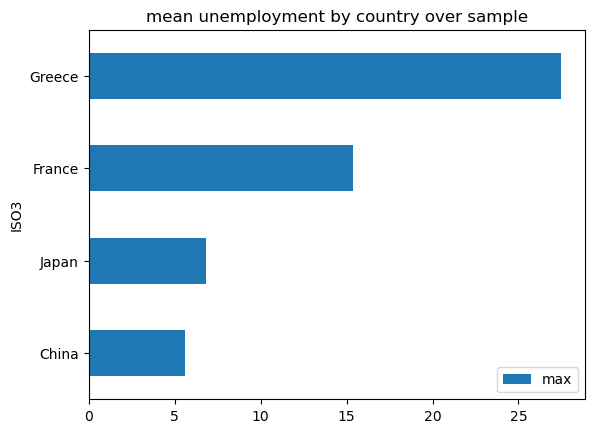

In [98]:
import matplotlib.pyplot as plt
df_plot.plot(kind = 'barh')
plt.title("mean unemployment by country over sample")

#### Filter Mean column only

<Axes: xlabel='year'>

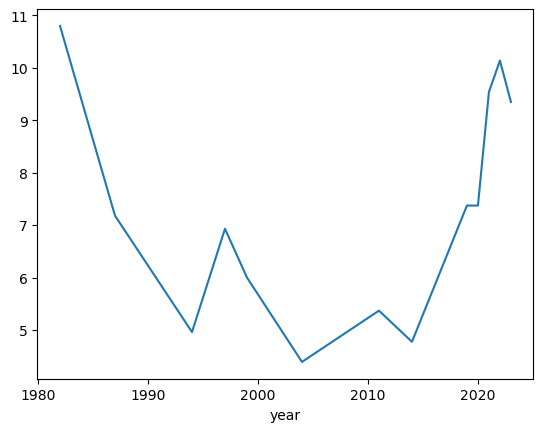

In [74]:
df_unemp_zimbabwe_final['unemp'].dropna().plot()

#### Graph

Text(0.5, 1.0, 'mean unemployment by country over sample')

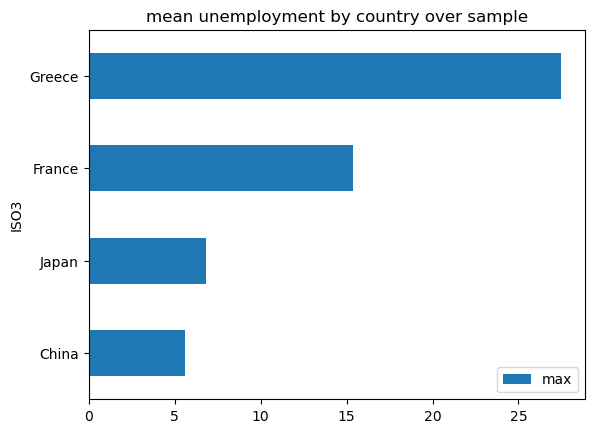

In [100]:
import matplotlib.pyplot as plt
df_plot.plot(kind = 'barh')
plt.title("mean unemployment by country over sample")

<Axes: xlabel='ISO3'>

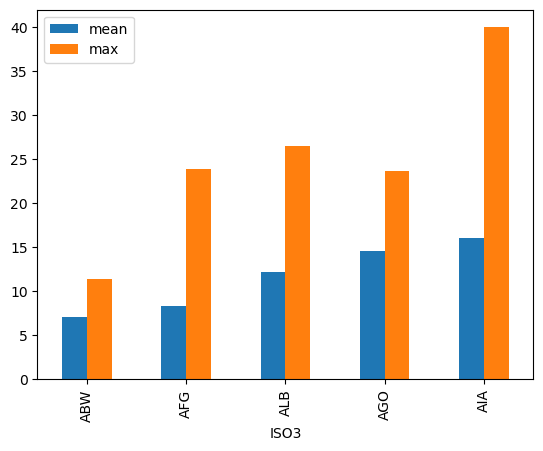

In [105]:
df_unemp_descriptive_bycountry[['mean', 'max']].head(5).sort_values(by = 'mean').plot(kind = 'bar')

#### Refresher: (1) on using dictionary to rename (2) filter specific country rows

In [106]:
# Website with country codes https://www.iban.com/country-codes
country_code = pd.read_html('https://www.iban.com/country-codes')[0]
country_code.head(2)

,Country,Alpha-2 code,Alpha-3 code,Numeric
0,Afghanistan,AF,AFG,4
1,Åland Islands,AX,ALA,248


In [85]:
country_map = dict(country_code[['Alpha-3 code', 'Country']].head(5).values)
country_map

{'AFG': 'Afghanistan',
 'ALA': 'Åland Islands',
 'ALB': 'Albania',
 'DZA': 'Algeria',
 'ASM': 'American Samoa'}

In [86]:
country_map = dict(country_code[['Alpha-3 code', 'Country']].values)
#country_map

In [109]:
country_list = ["JPY", "GIB", "FRA"]
df_plot = df_unemp_descriptive_bycountry['max'].rename(country_map, axis='index').sort_values()
df_plot.head(2)

ISO3
Qatar    1.480
Benin    2.647
Name: max, dtype: float64

In [88]:
df_plot = df_plot.to_frame().query("ISO3 in ['France', 'Japan', 'China', 'Greece']")
df_plot.head(2)

,max
ISO3,
China,5.617
Japan,6.800


Text(0.5, 1.0, 'Max Unemployment by Country in Sample')

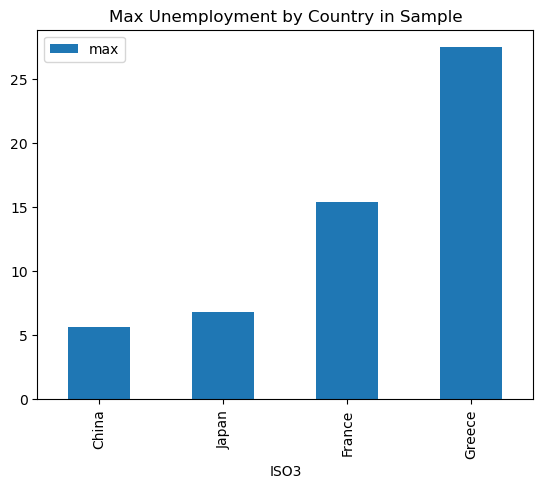

In [89]:
df_plot.plot(kind = 'bar')
plt.title("Max Unemployment by Country in Sample")

### 1.2.2 Groupby date (Get stats by date)

- In this case unemployment average, max etc BY DATE!!

df_unemp.head(2)

In [119]:
df_unemp.drop('EUS_unemp', axis=1).head(2)

,ISO3,year,unemp
0,ZWE,2023.0,9.348
1,ZWE,2022.0,10.139


In [122]:
df_unemp_datetime = df_unemp.copy()
df_unemp_datetime.year = pd.to_datetime(df_unemp_datetime.year, format = "%Y")
df_unemp_datetime.head(2)

,ISO3,year,unemp,EUS_unemp
0,ZWE,2023-01-01,9.348,NaN
1,ZWE,2022-01-01,10.139,NaN


In [123]:
df_unemp_descriptive_bydate = df_unemp.groupby('year')['unemp'].describe()
df_unemp_descriptive_bydate.head(2)

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
1760.0,1.0,3.626304,NaN,3.626304,3.626304,3.626304,3.626304,3.626304
1761.0,1.0,3.114833,NaN,3.114833,3.114833,3.114833,3.114833,3.114833


<Axes: xlabel='year'>

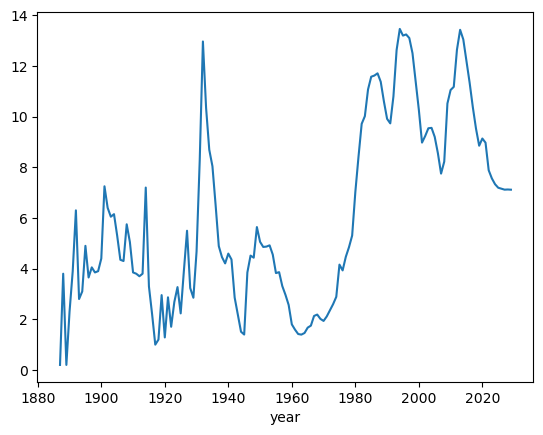

In [124]:
df_unemp.query("ISO3 in ['FRA', 'DEU', 'ESP', 'ITA']").groupby('year')['unemp'].mean().plot()